In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

from sys import path # Needed if running code from repo
path.append("../../../")

import larp
import larp.io as lpio

In [2]:
def plot(field, quadtree, network = None):
    # Generate the field image
    display, extent = field.to_image(resolution=400, return_extent=True)
    # Create figure and subplots
    _, axs = plt.subplots(1, 3, sharey=True, dpi=200)
    # Plot the field image on first subplot
    img = axs[0].imshow(display, cmap='jet', extent=extent)
    img.set_clim(0.0, 1.0)

    # Plot the field image again on second subplot
    img = axs[1].imshow(display, cmap='jet', extent=extent)
    img.set_clim(0.0, 1.0)
    # Get edge boundaries and zones from quadtree
    edge_bounds_lines = quadtree.to_boundary_lines_collection(margin=0.2)
    edge_bounds_lines_zones = quadtree.get_quad_zones()

    # Plot boundaries with zone-based colors
    for i in range(0, len(edge_bounds_lines), 2):
        zone = edge_bounds_lines_zones[i // 2]
        c = cm.jet(quadtree.ZONEToMaxRANGE[zone]) if zone > 0 else "#e4ebff"
        axs[1].plot(*edge_bounds_lines[i:i+2], c=c, alpha=0.8, linewidth=1)


    if network is not None:
        routes_lines = network.to_line_collection()

        lc = LineCollection(routes_lines, color="#fff", alpha=0.25, linewidth=0.5)
        axs[1].add_collection(lc)
    
    display, extent = quadtree.to_image(return_zone=False, return_extent=True) # Need to improve

    # Plot the quad sectors image
    img = axs[2].imshow(display, cmap='jet', extent=extent, interpolation='nearest')
    img.set_clim(0.0, 1.0)
    plt.tight_layout()

    return axs

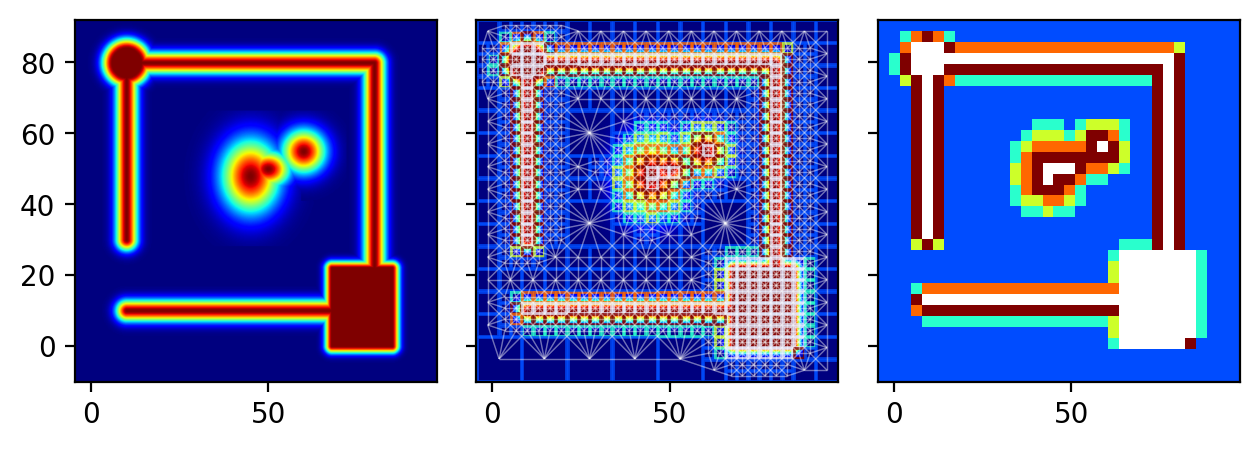

In [3]:
edges = np.arange(0.2, 0.8, 0.2)

field = lpio.loadRGeoJSONFile("walled_room.rgj", size_offset=10)
quadtree = larp.quad.QuadTree(field=field,
                                minimum_length_limit=2,
                                edge_bounds=edges,
                                build_tree=True)

qfield = larp.QPotentailField(quadtree)
path_planner = larp.pp.QuadPlanner(quadtree)

plot(qfield, quadtree, path_planner.network)
plt.show()

-------- Time to change field and update quadtree --------
CPU times: total: 516 ms
Wall time: 516 ms

--------- Time to update quad network in planner ---------
CPU times: total: 15.6 ms
Wall time: 6.8 ms


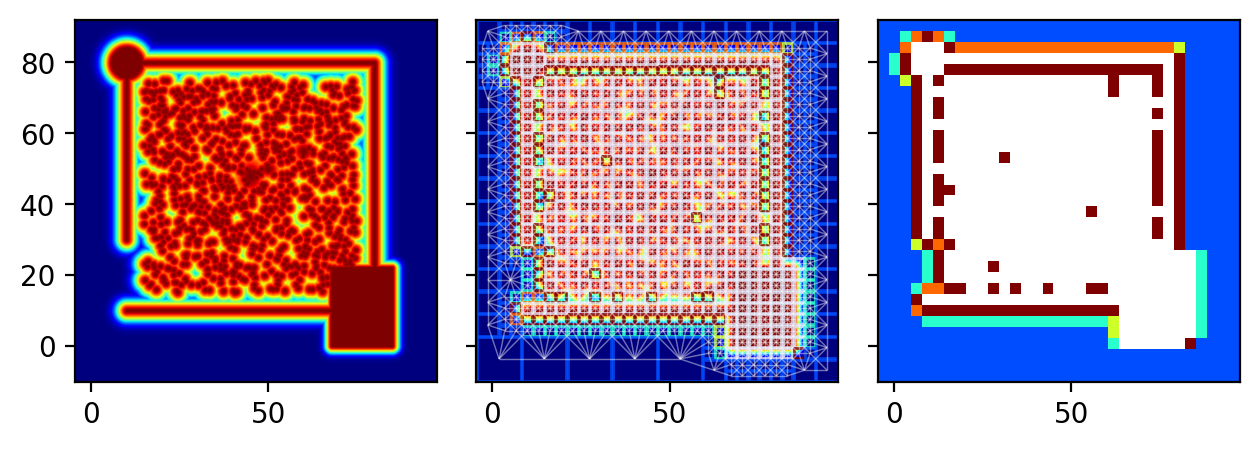

In [4]:
points = larp.PotentialField([larp.PointRGJ(np.random.rand(2)*(75-15)+15, repulsion=[[10, 0], [0, 10]]) for _ in range(1000)])

print("-------- Time to change field and update quadtree --------")
%time added_idxs = qfield.addField(points)
print("")

print("--------- Time to update quad network in planner ---------")
%time path_planner.refresh_network()

plot(qfield, quadtree, path_planner.network)
plt.show()


-------- Time to change field and update quadtree --------
CPU times: total: 15.6 ms
Wall time: 23.4 ms

--------- Time to update quad network in planner ---------
CPU times: total: 15.6 ms
Wall time: 23.1 ms


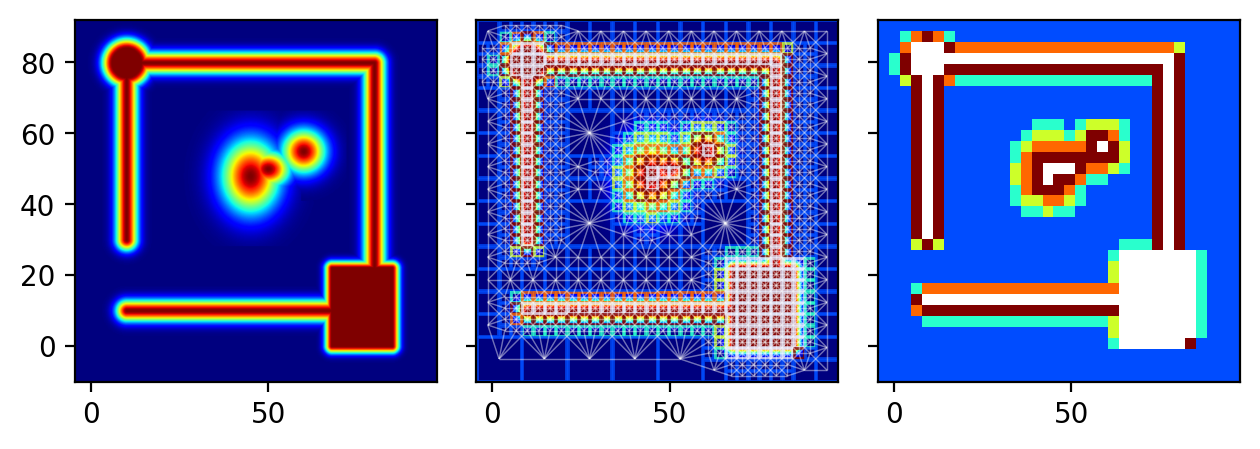

In [5]:
# Remove RGJs
print("-------- Time to change field and update quadtree --------")
%time qfield.delRGJ(added_idxs)
print()

print("--------- Time to update quad network in planner ---------")
%time path_planner.refresh_network()

plot(qfield, quadtree, path_planner.network)
plt.show()